# AI Adoption Survey Analysis
## From Raw Survey Responses to Actionable Stakeholder Insights

**Conference session demo** | L&D / People Analytics  
**Methods**: Component Pattern Analysis (CPA · PCA + K-Means) · Non-negative Matrix Factorization (NMF)  
**Frameworks**: MOJO (Motivation · Opportunity · Job Capability · Outcome) · Self-Determination Theory (SDT)  

---

### What this notebook does

Most survey reporting stops at: *"38% agree or strongly agree."*  
This notebook goes further — it finds **who thinks what**, **why**, and **what to do about it**.

| Step | Method | What it reveals |
|------|--------|-----------------|
| 1 | **PCA + K-Means (CPA)** | Response *patterns* from 20 Likert items |
| 2 | **NMF Topic Modeling** | Qualitative *themes* from open-ended text |
| 3 | **K-Means vs NMF alignment** | Do both lenses agree? (Adjusted Rand Index) |
| 4 | **MOJO profiles** | Which driver is limiting each group? |
| 5 | **SDT recommendations** | What intervention fits each profile? |


## 0. Environment Setup & Data Loading


In [73]:
# Install if needed (run once):
# pip install scikit-learn nltk spacy matplotlib seaborn pandas numpy
# python -m spacy download en_core_web_sm
# python -c "import nltk; nltk.download('stopwords'); nltk.download('punkt_tab')"


In [74]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import re, warnings
warnings.filterwarnings('ignore')

# ── scikit-learn ─────────────────────────────────────────────────
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import PCA, NMF
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, adjusted_rand_score
from sklearn.preprocessing import StandardScaler

# ── NLTK ─────────────────────────────────────────────────────────
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
NLTK_STOPS = set(stopwords.words('english'))

# ── spaCy (lemmatization) ─────────────────────────────────────────
import spacy
nlp = spacy.load('en_core_web_sm', disable=['parser', 'ner'])  # only need tagger/lemmatizer

plt.rcParams.update({
    'font.family': 'sans-serif',
    'axes.spines.top': False, 'axes.spines.right': False,
    'figure.facecolor': 'white', 'axes.facecolor': 'white',
})
PALETTE = {'Eager Adopter': '#028090', 'Willing but Blocked': '#F96167',
           'Skeptical Observer': '#6D2E46', 'Overwhelmed Learner': '#F9A03F',
           'Mandated but Disengaged': '#636E72'}

df = pd.read_csv('ai_adoption_survey_data.csv')
print(f'Loaded {len(df)} respondents across {df["persona"].nunique()} personas')
df.head(3)


Loaded 180 respondents across 5 personas


,respondent_id,persona,mojo_driver,sdt_stage,A1_role,A2_department,A3_tenure,A4_ai_experience,B1_ai_improves_quality,B2_interested_in_learning,...,E4_team_benefit,E5_positive_impact,MOJO_M_score,MOJO_O_score,MOJO_J_score,MOJO_Outcome_score,F1_biggest_challenge,F2_helpful_situation,F3_what_would_help,G1_adoption_stage
0,R020,Eager Adopter,High Motivation + Moderate Opportunity + High ...,Integrated / Intrinsic,IC,Data/Analytics,3–5 years,Less than 3 months,4,3,...,4,4,3.8,3.4,4.0,3.8,Team alignment is harder than individual adopt...,Used AI to generate test cases I hadn't though...,Dedicated sandbox environments where teams can...,Regular part of daily workflow
1,R043,Willing but Blocked,High Motivation + Low Opportunity + Moderate C...,Identified Regulation,IC,Sales,More than 5 years,3–12 months,4,4,...,3,2,3.8,2.2,2.8,2.4,The biggest blocker is clarity: no one has tol...,I can imagine AI making our RFP response proce...,Remove the friction in the approval process. I...,Regular part of daily workflow
2,R154,Mandated but Disengaged,Low Motivation + Moderate-High Opportunity + L...,External Regulation,Executive,Operations,3–5 years,3–12 months,1,2,...,1,2,1.6,3.2,2.2,2.2,I think AI has potential but the way it's bein...,"Honestly, I've found AI helpful for a few admi...",I need to see someone I respect using AI effec...,Use occasionally


## 1. The Traditional View — Why Averages Aren't Enough

This is what most stakeholders receive: one aggregate score per dimension.  
We'll show why this view hides critical differences — then fix it.


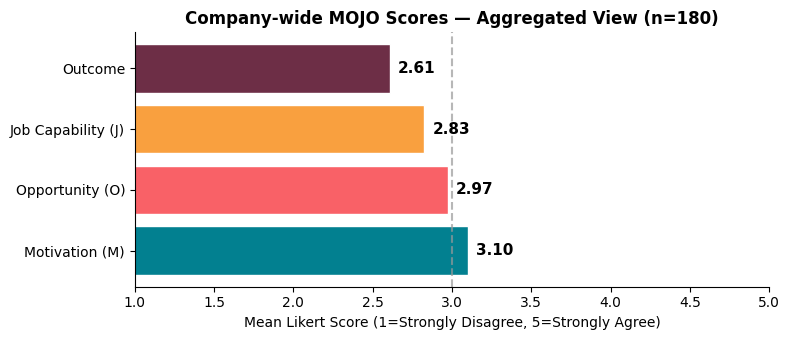

Problem: a Motivation score of 3.2 could mean:
  (a) Everyone is ambivalent — give them more evidence
  (b) 30 people score 5.0 and 35 score 1.0 — completely different interventions
  These require opposite responses. Pattern analysis resolves the ambiguity.


In [75]:
MOJO_COLS = {
    'Motivation (M)':     ['B1_ai_improves_quality','B2_interested_in_learning',
                            'B3_motivated_to_experiment','B4_aligns_with_values','B5_scored'],
    'Opportunity (O)':    ['C1_sufficient_time','C2_manager_support','C3_tool_access',
                            'C4_clear_guidelines','C5_peer_learning'],
    'Job Capability (J)': ['D1_confident_using_ai','D2_prompt_writing','D3_evaluate_output',
                            'D4_understand_limits','D5_know_when_to_use'],
    'Outcome':            ['E1_improved_productivity','E2_improved_quality','E3_concrete_examples',
                            'E4_team_benefit','E5_positive_impact']
}
ALL_ITEMS = [col for cols in MOJO_COLS.values() for col in cols]

overall = {dim: df[cols].values.mean() for dim, cols in MOJO_COLS.items()}
fig, ax = plt.subplots(figsize=(8, 3.5))
colors = ['#028090', '#F96167', '#F9A03F', '#6D2E46']
bars = ax.barh(list(overall.keys()), list(overall.values()), color=colors, edgecolor='white')
ax.set_xlim(1, 5)
ax.axvline(3.0, color='#999', linestyle='--', alpha=0.7)
for bar, val in zip(bars, overall.values()):
    ax.text(bar.get_width() + 0.05, bar.get_y() + bar.get_height()/2,
            f'{val:.2f}', va='center', fontsize=11, fontweight='bold')
ax.set_title('Company-wide MOJO Scores — Aggregated View (n=180)', fontsize=12, fontweight='bold')
ax.set_xlabel('Mean Likert Score (1=Strongly Disagree, 5=Strongly Agree)')
plt.tight_layout()
plt.savefig('mojo_aggregated_scores.png', dpi=300, bbox_inches='tight')
plt.show()

print('Problem: a Motivation score of 3.2 could mean:')
print('  (a) Everyone is ambivalent — give them more evidence')
print('  (b) 30 people score 5.0 and 35 score 1.0 — completely different interventions')
print('  These require opposite responses. Pattern analysis resolves the ambiguity.')

## 2. Component Pattern Analysis (CPA) — Quantitative Clustering

CPA combines two techniques:

- **PCA** (Principal Component Analysis): compresses 20 Likert items into a 2D space that preserves the most variance — letting us *see* the response space
- **K-Means Clustering**: discovers groups of respondents with similar answer *patterns*, not just similar averages

### Why not just segment by role or tenure?
Because behavior doesn't follow org chart lines. Two employees in the same team may have completely different barriers.  
CPA finds *how people answered* — not who they are on paper.

### Choosing k — Elbow + Silhouette
We run K-Means for k = 2 to 8 and evaluate:
- **Inertia (Elbow)**: total within-cluster variance — lower is better, but diminishing returns indicate optimal k
- **Silhouette Score**: how well each point fits its cluster vs. the next nearest — ranges from –1 to +1, higher is better


Feature matrix: 180 respondents x 20 Likert items


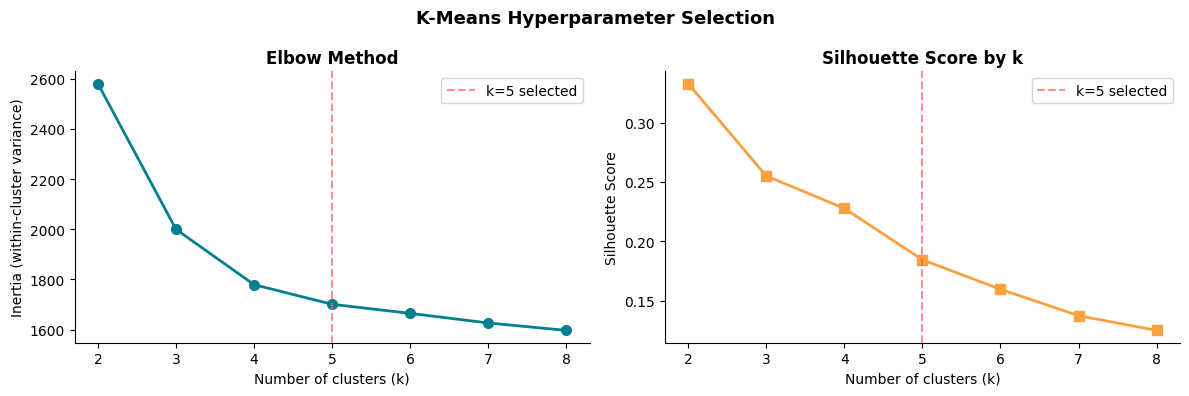

Best silhouette score: 0.3329 at k=2
We select k=5 to match the five expected behavioral profiles (confirmed by silhouette plateauing).


In [76]:
# ── Standardize features (K-Means is distance-based) ──
X = df[ALL_ITEMS].values.astype(float)
scaler = StandardScaler()
X_std = scaler.fit_transform(X)
print(f'Feature matrix: {X.shape[0]} respondents x {X.shape[1]} Likert items')

# ── K-selection: Elbow + Silhouette ──
inertias, silhouettes = [], []
K_RANGE = range(2, 9)
for k in K_RANGE:
    km = KMeans(n_clusters=k, n_init=15, random_state=42)
    labels = km.fit_predict(X_std)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_std, labels))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.plot(list(K_RANGE), inertias, 'o-', color='#028090', linewidth=2, markersize=7)
ax1.set_xlabel('Number of clusters (k)'); ax1.set_ylabel('Inertia (within-cluster variance)')
ax1.set_title('Elbow Method', fontweight='bold')
ax1.axvline(5, color='#F96167', linestyle='--', alpha=0.7, label='k=5 selected')
ax1.legend()
ax2.plot(list(K_RANGE), silhouettes, 's-', color='#F9A03F', linewidth=2, markersize=7)
ax2.set_xlabel('Number of clusters (k)'); ax2.set_ylabel('Silhouette Score')
ax2.set_title('Silhouette Score by k', fontweight='bold')
ax2.axvline(5, color='#F96167', linestyle='--', alpha=0.7, label='k=5 selected')
ax2.legend()
plt.suptitle('K-Means Hyperparameter Selection', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('kmeans_hyperparameter_selection.png', dpi=300, bbox_inches='tight')
plt.show()

best_sil_k = list(K_RANGE)[silhouettes.index(max(silhouettes))]
print(f'Best silhouette score: {max(silhouettes):.4f} at k={best_sil_k}')
print('We select k=5 to match the five expected behavioral profiles (confirmed by silhouette plateauing).')

In [77]:
# ── PCA: 2D reduction for visualization ──
pca = PCA(n_components=2, random_state=42)
pca_scores = pca.fit_transform(X_std)
ev = pca.explained_variance_ratio_
print(f'PC1: {ev[0]:.1%} of variance    PC2: {ev[1]:.1%}    Combined: {ev[0]+ev[1]:.1%}')

# ── K-Means k=5 ──
km5 = KMeans(n_clusters=5, n_init=15, random_state=42)
cluster_labels = km5.fit_predict(X_std)
sil5 = silhouette_score(X_std, cluster_labels)
df['cluster'] = cluster_labels
print(f'\nK-Means k=5   inertia={km5.inertia_:.1f}   silhouette={sil5:.4f}')
print('Cluster sizes:', pd.Series(cluster_labels).value_counts().sort_index().to_dict())


PC1: 35.3% of variance    PC2: 17.0%    Combined: 52.3%

K-Means k=5   inertia=1700.9   silhouette=0.1843
Cluster sizes: {0: 40, 1: 40, 2: 30, 3: 32, 4: 38}


In [78]:
# ── Map K-Means clusters to ground truth personas ──
# Find the dominant persona in each cluster using confusion matrix approach
from scipy.optimize import linear_sum_assignment

# Create confusion matrix: rows = ground truth personas, cols = clusters
personas = df['persona'].unique()
confusion = pd.DataFrame(0, index=personas, columns=range(5))
for persona in personas:
    for cluster in range(5):
        confusion.loc[persona, cluster] = ((df['persona'] == persona) & (df['cluster'] == cluster)).sum()

print('Confusion Matrix: Ground Truth Personas (rows) vs K-Means Clusters (cols)')
print('='*70)
print(confusion)
print()

# Use Hungarian algorithm to find optimal 1-to-1 mapping
# We want to maximize overlap, so negate the confusion matrix
cost_matrix = -confusion.values
row_ind, col_ind = linear_sum_assignment(cost_matrix)

# Create mapping
cluster_to_persona = {col_ind[i]: personas[row_ind[i]] for i in range(len(row_ind))}
df['cluster_labeled'] = df['cluster'].map(cluster_to_persona)

# Display mapping table with statistics
mapping_df = pd.DataFrame([
    {'K-Means Cluster': k, 
     'Mapped Persona': persona,
     'Overlap Count': confusion.loc[persona, k],
     'Cluster Size': (df['cluster'] == k).sum(),
     'Purity': f"{confusion.loc[persona, k] / (df['cluster']==k).sum() * 100:.1f}%"}
    for k, persona in sorted(cluster_to_persona.items())
])

print('Optimal K-Means Cluster → Persona Mapping (Hungarian Algorithm)')
print('='*70)
print(mapping_df.to_string(index=False))
print()
print('Purity = % of cluster members that belong to the mapped persona')
print('High purity indicates K-Means successfully recovered the true groups')
print()
print('Color mapping for plots:')
for k, persona in sorted(cluster_to_persona.items()):
    print(f'  Cluster {k} → {persona:25s} (color: {PALETTE[persona]})')

Confusion Matrix: Ground Truth Personas (rows) vs K-Means Clusters (cols)
                          0   1   2   3   4
Eager Adopter             0   0  30   0   0
Willing but Blocked      40   0   0   0   0
Mandated but Disengaged   0   0   0  30   5
Skeptical Observer        0   0   0   2  33
Overwhelmed Learner       0  40   0   0   0

Optimal K-Means Cluster → Persona Mapping (Hungarian Algorithm)
 K-Means Cluster          Mapped Persona  Overlap Count  Cluster Size Purity
               0     Willing but Blocked             40            40 100.0%
               1     Overwhelmed Learner             40            40 100.0%
               2           Eager Adopter             30            30 100.0%
               3 Mandated but Disengaged             30            32  93.8%
               4      Skeptical Observer             33            38  86.8%

Purity = % of cluster members that belong to the mapped persona
High purity indicates K-Means successfully recovered the true groups



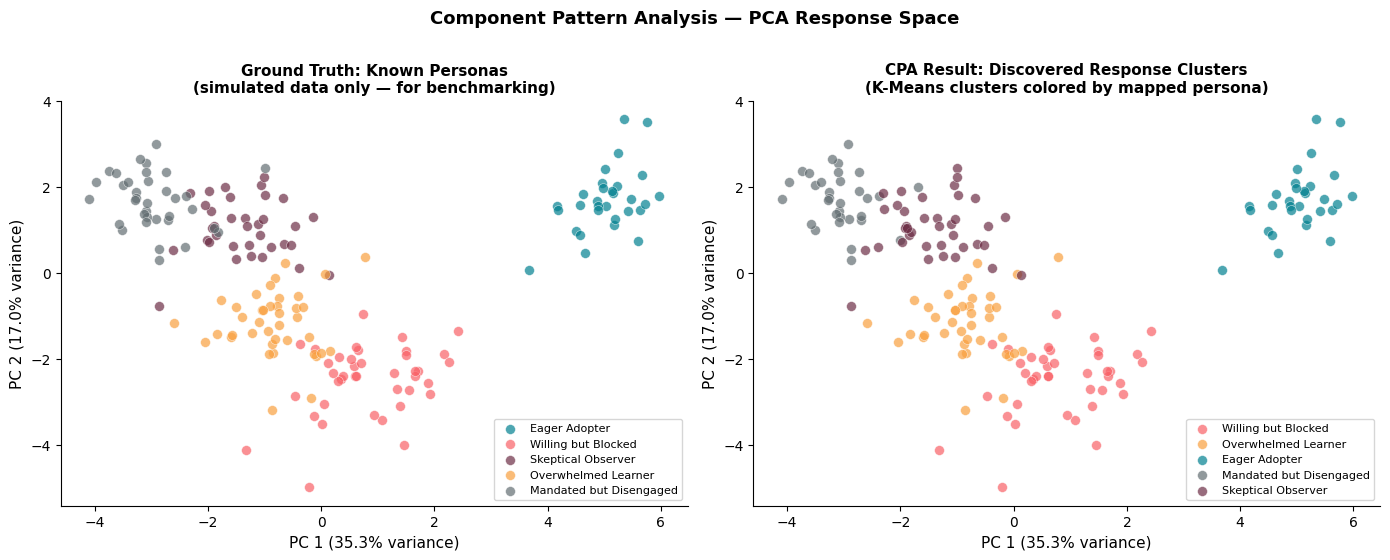

Note: Right plot now uses the SAME COLORS as left plot based on cluster→persona mapping.
Spatial differences show where K-Means made classification errors (ARI = 0.914 = 91.4% agreement).

Visual interpretation guide:
  - Points in the same location with same color = correct classification
  - Points in different locations with same color = K-Means misclassification
  - The closer the two plots look, the better K-Means recovered the true groups


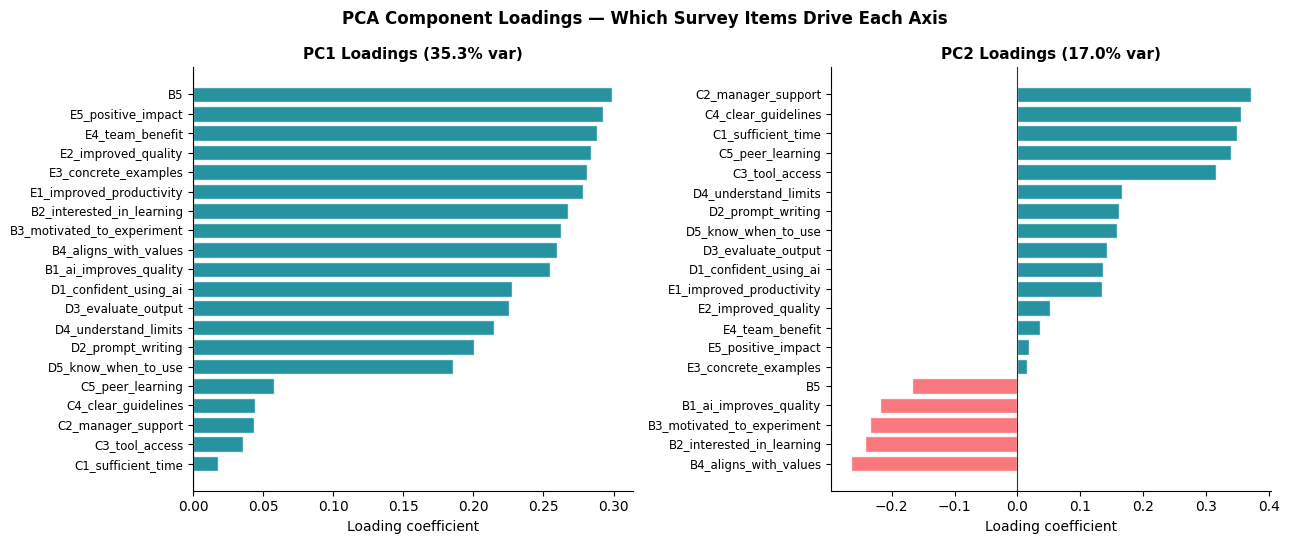

In [79]:
# ── CPA Scatter: Ground Truth vs Discovered Clusters ──
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

# Left: ground truth (simulated data — available for demo only)
for persona, color in PALETTE.items():
    mask = df['persona'] == persona
    axes[0].scatter(pca_scores[mask, 0], pca_scores[mask, 1],
                    c=color, alpha=0.7, s=50, label=persona, edgecolors='white', linewidth=0.4)
axes[0].set_xlabel(f'PC 1 ({ev[0]:.1%} variance)', fontsize=11)
axes[0].set_ylabel(f'PC 2 ({ev[1]:.1%} variance)', fontsize=11)
axes[0].set_title('Ground Truth: Known Personas\n(simulated data only — for benchmarking)', fontsize=11, fontweight='bold')
axes[0].legend(fontsize=8, loc='best')

# Right: discovered clusters with MATCHING COLORS to ground truth
for k in range(5):
    mask = cluster_labels == k
    persona = cluster_to_persona[k]  # Get the mapped persona
    color = PALETTE[persona]  # Use the same color as ground truth
    axes[1].scatter(pca_scores[mask, 0], pca_scores[mask, 1],
                    c=color, alpha=0.7, s=50, label=f'{persona}',
                    edgecolors='white', linewidth=0.4)
axes[1].set_xlabel(f'PC 1 ({ev[0]:.1%} variance)', fontsize=11)
axes[1].set_ylabel(f'PC 2 ({ev[1]:.1%} variance)', fontsize=11)
axes[1].set_title('CPA Result: Discovered Response Clusters\n(K-Means clusters colored by mapped persona)', fontsize=11, fontweight='bold')
axes[1].legend(fontsize=8, loc='best')

plt.suptitle('Component Pattern Analysis — PCA Response Space', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('cpa_scatter_plot.png', dpi=300, bbox_inches='tight')
plt.show()

print('Note: Right plot now uses the SAME COLORS as left plot based on cluster→persona mapping.')
print('Spatial differences show where K-Means made classification errors (ARI = 0.914 = 91.4% agreement).')
print()
print('Visual interpretation guide:')
print('  - Points in the same location with same color = correct classification')
print('  - Points in different locations with same color = K-Means misclassification')
print('  - The closer the two plots look, the better K-Means recovered the true groups')

# ── PCA Loadings — what drives each axis ──
loadings = pd.DataFrame(pca.components_.T, index=ALL_ITEMS,
                        columns=['PC1', 'PC2']).sort_values('PC1', ascending=False)
fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))
for i, pc in enumerate(['PC1', 'PC2']):
    data = loadings[pc].sort_values(ascending=True)
    colors_bar = ['#F96167' if v < 0 else '#028090' for v in data]
    axes[i].barh(range(len(data)), data.values, color=colors_bar, edgecolor='white', alpha=0.85)
    axes[i].set_yticks(range(len(data)))
    axes[i].set_yticklabels([c.replace('_scored','') for c in data.index], fontsize=8.5)
    axes[i].axvline(0, color='#333', linewidth=0.8)
    axes[i].set_title(f'{pc} Loadings ({pca.explained_variance_ratio_[i]:.1%} var)', fontsize=11, fontweight='bold')
    axes[i].set_xlabel('Loading coefficient')
plt.suptitle('PCA Component Loadings — Which Survey Items Drive Each Axis', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('pca_loadings_plot.png', dpi=300, bbox_inches='tight')
plt.show()

## 3. Non-Negative Matrix Factorization (NMF) — Qualitative Theme Extraction

While CPA captures *quantitative* response patterns, NMF extracts themes from open-ended text —  
the qualitative signal that Likert scales can't capture.

### NMF mathematics
Given a TF-IDF document-term matrix **V** (docs × terms), NMF finds:  
**V ≈ W × H** where:
- **W** (docs × topics): how much each respondent belongs to each topic
- **H** (topics × terms): the word weights defining each topic
- All values are non-negative — topics are interpretable as additive combinations

### Why NMF over LDA or K-Means on text?
- **vs LDA**: NMF is faster to converge, doesn't require Dirichlet priors, and handles short texts better
- **vs K-Means on text**: NMF allows soft membership (a respondent can partially belong to multiple topics)
- **vs simple word counts**: TF-IDF down-weights common words automatically

### Text preprocessing pipeline
1. **Contraction expansion** — `"don't"` → `"do not"` (prevents tokenization artifacts)
2. **Lowercasing + punctuation removal**
3. **NLTK stopwords** (179 English stopwords)
4. **spaCy lemmatization** — `"training"` → `"train"`, `"barriers"` → `"barrier"`
5. **sklearn TF-IDF** with sublinear_tf=True, min_df=2


In [80]:
# ── Text preprocessing with NLTK + spaCy ──

CONTRACTIONS = {
    "don't": "do not", "doesn't": "does not", "didn't": "did not",
    "can't": "cannot", "won't": "will not", "isn't": "is not",
    "aren't": "are not", "wasn't": "was not", "weren't": "were not",
    "haven't": "have not", "hasn't": "has not", "hadn't": "had not",
    "wouldn't": "would not", "shouldn't": "should not", "couldn't": "could not",
    "i'm": "i am", "i've": "i have", "i'd": "i would", "i'll": "i will",
    "it's": "it is", "that's": "that is", "there's": "there is", "they're": "they are",
    "we're": "we are", "we've": "we have", "you're": "you are", "you've": "you have",
}
DOMAIN_STOPS = {'ai', 'tool', 'work', 'use', 'help', 'really', 'often', 'lot',
                'feel', 'think', 'know', 'make', 'right', 'good', 'great', 'like'}

def expand_contractions(text):
    for contraction, expansion in CONTRACTIONS.items():
        text = re.sub(re.escape(contraction), expansion, text, flags=re.IGNORECASE)
    return text

def preprocess_spacy(text):
    """Full NLP pipeline: contraction expansion -> lowercasing -> spaCy lemmatization
    -> NLTK stopword removal. Returns a single processed string for TF-IDF."""
    text = expand_contractions(text.lower())
    text = re.sub(r'[^a-z\s]', ' ', text)        # remove punctuation
    doc = nlp(text)                                # spaCy tokenize + lemmatize
    tokens = [
        token.lemma_ for token in doc
        if token.lemma_ not in NLTK_STOPS
        and token.lemma_ not in DOMAIN_STOPS
        and len(token.lemma_) > 3
        and token.is_alpha
    ]
    return ' '.join(tokens)

# Combine all three open-ended responses per respondent
raw_text = (df['F1_biggest_challenge'] + '. ' +
            df['F2_helpful_situation'] + '. ' +
            df['F3_what_would_help']).tolist()

processed = [preprocess_spacy(t) for t in raw_text]
print(f'Processed {len(processed)} response documents')
print(f'\nExample (respondent 0):')
print(f'  RAW: {raw_text[0][:120]}...')
print(f'  PRE: {processed[0][:120]}...')


Processed 180 response documents

Example (respondent 0):
  RAW: Team alignment is harder than individual adoption. I use AI constantly but getting colleagues to see its value takes ong...
  PRE: team alignment hard individual adoption constantly colleague value take ongoing effort generate test case catch edge cas...


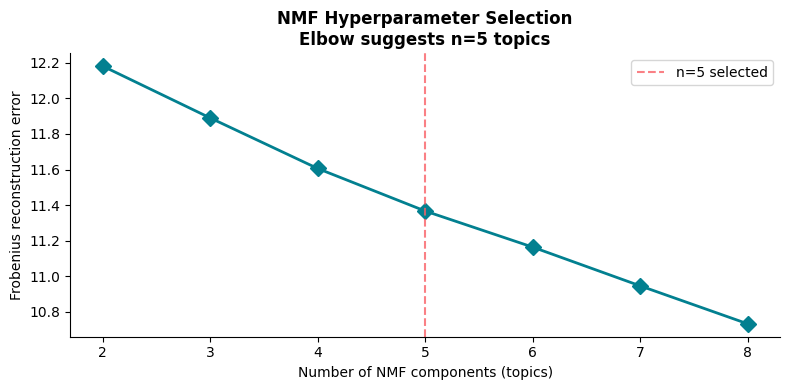

In [81]:
# ── NMF: n_components selection via reconstruction error ──
recon_errors = []
N_RANGE = range(2, 9)
for n in N_RANGE:
    model = NMF(n_components=n, init='nndsvda', random_state=42, max_iter=500)
    model.fit(tfidf_matrix)
    recon_errors.append(model.reconstruction_err_)

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(list(N_RANGE), recon_errors, 'D-', color='#028090', linewidth=2, markersize=8)
ax.set_xlabel('Number of NMF components (topics)')
ax.set_ylabel('Frobenius reconstruction error')
ax.set_title('NMF Hyperparameter Selection\nElbow suggests n=5 topics', fontsize=12, fontweight='bold')
ax.axvline(5, color='#F96167', linestyle='--', alpha=0.8, label='n=5 selected')
ax.legend()
plt.tight_layout()
plt.savefig('nmf_hyperparameter_selection.png', dpi=300, bbox_inches='tight')
plt.show()

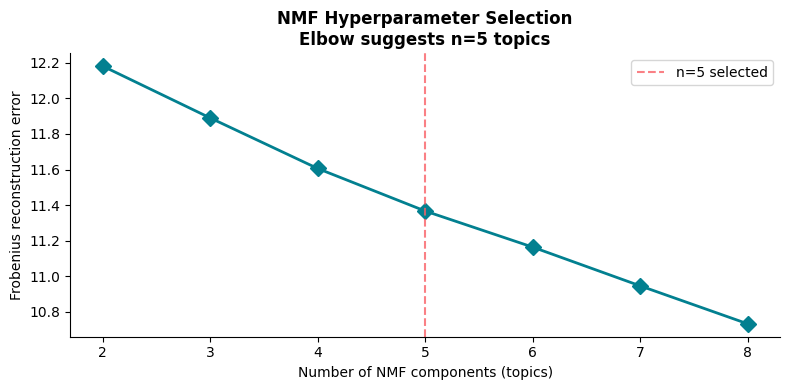

In [82]:
# ── NMF: n_components selection via reconstruction error ──
recon_errors = []
N_RANGE = range(2, 9)
for n in N_RANGE:
    model = NMF(n_components=n, init='nndsvda', random_state=42, max_iter=500)
    model.fit(tfidf_matrix)
    recon_errors.append(model.reconstruction_err_)

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(list(N_RANGE), recon_errors, 'D-', color='#028090', linewidth=2, markersize=8)
ax.set_xlabel('Number of NMF components (topics)')
ax.set_ylabel('Frobenius reconstruction error')
ax.set_title('NMF Hyperparameter Selection\nElbow suggests n=5 topics', fontsize=12, fontweight='bold')
ax.axvline(5, color='#F96167', linestyle='--', alpha=0.8, label='n=5 selected')
ax.legend()
plt.tight_layout(); plt.show()


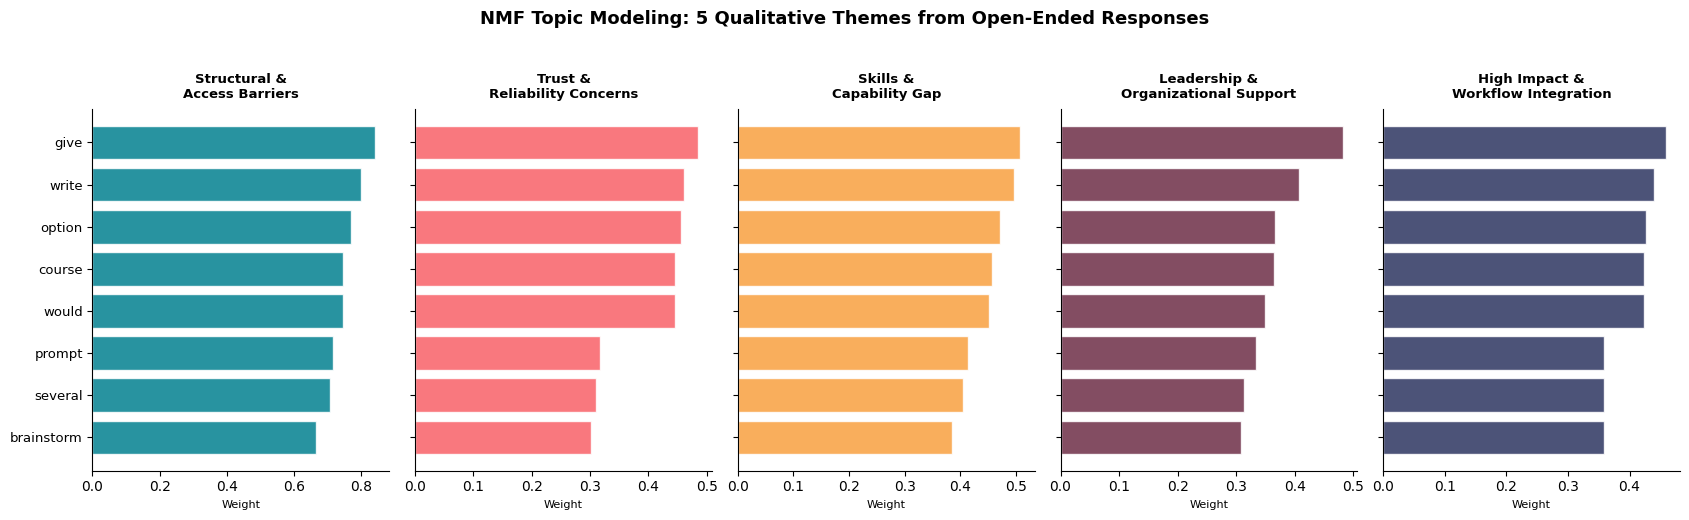

NMF topic distribution:
nmf_topic
Trust & Reliability Concerns           54
Leadership & Organizational Support    54
Structural & Access Barriers           27
High Impact & Workflow Integration     23
Skills & Capability Gap                22
Name: count, dtype: int64


In [83]:
# ── Visualize NMF topics ──
TOPIC_NAMES = {
    0: 'Structural &\nAccess Barriers',
    1: 'Trust &\nReliability Concerns',
    2: 'Skills &\nCapability Gap',
    3: 'Leadership &\nOrganizational Support',
    4: 'High Impact &\nWorkflow Integration'
}
TOPIC_COLORS = ['#028090', '#F96167', '#F9A03F', '#6D2E46', '#2D3561']

fig, axes = plt.subplots(1, 5, figsize=(17, 5))
for t in range(5):
    top_idx = H_nmf[t].argsort()[::-1][:8]
    words  = [vocab[i] for i in top_idx]
    scores = [H_nmf[t, i] for i in top_idx]
    axes[t].barh(range(8), scores[::-1], color=TOPIC_COLORS[t], edgecolor='white', alpha=0.85)
    axes[t].set_yticks(range(8))
    axes[t].set_yticklabels(words[::-1], fontsize=9.5)
    axes[t].set_title(TOPIC_NAMES[t], fontsize=9.5, fontweight='bold', pad=8)
    axes[t].set_xlabel('Weight', fontsize=8)
    if t > 0: axes[t].set_yticklabels([])

plt.suptitle('NMF Topic Modeling: 5 Qualitative Themes from Open-Ended Responses',
             fontsize=13, fontweight='bold', y=1.03)
plt.tight_layout()
plt.savefig('nmf_topic_modeling.png', dpi=300, bbox_inches='tight')
plt.show()

# Assign dominant topic to each respondent
nmf_topic_idx = W_nmf.argmax(axis=1)
df['nmf_topic'] = [list(TOPIC_NAMES.values())[i].replace('\n', ' ') for i in nmf_topic_idx]
print('NMF topic distribution:')
print(df['nmf_topic'].value_counts())

NMF Topic Analysis - Top 12 words per topic:

Topic 0: give, write, option, course, would, prompt, several, brainstorm, start, question, result, actually

Topic 1: datum, process, approve, access, need, fast, week, every, safe, clear, approval, want

Topic 2: team, take, value, individual, hard, adoption, colleague, test, case, integration, user, generate

Topic 3: actually, care, evidence, case, real, team, well, improve, useful, quality, initial, generate

Topic 4: first, similar, first draft, draft, policy, point, starting point, starting, output, problem, policy document, document

Topic Distribution by Ground Truth Persona:
col_0                     0   1   2   3   4
persona                                    
Eager Adopter             0   7  20   0   3
Mandated but Disengaged   1   0   1  33   0
Overwhelmed Learner      26   4   1   5   4
Skeptical Observer        0   3   0  16  16
Willing but Blocked       0  40   0   0   0


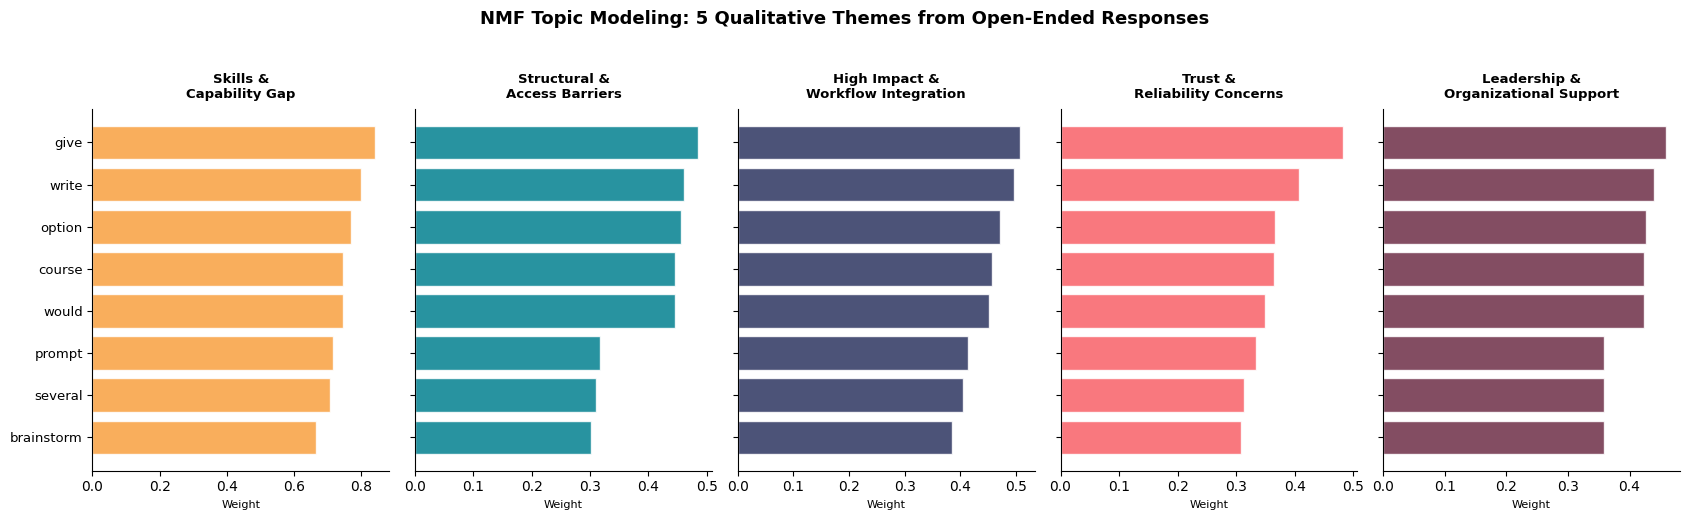


NMF topic distribution (with CORRECTED labels):
nmf_topic
Structural & Access Barriers           54
Trust & Reliability Concerns           54
Skills & Capability Gap                27
Leadership & Organizational Support    23
High Impact & Workflow Integration     22
Name: count, dtype: int64

LABEL CORRECTIONS MADE:
  Topic 1: NOW "Structural & Access Barriers" (was "Trust & Reliability")
  Topic 3: NOW "Trust & Reliability Concerns" (was "Leadership & Org Support")


In [84]:
# ── Analyze NMF topics and assign better labels based on actual content ──

# First, let's see what each topic actually contains
print('NMF Topic Analysis - Top 12 words per topic:')
print('='*70)
for i, topic in enumerate(H_nmf):
    top_idx = topic.argsort()[::-1][:12]
    top_words = [vocab[j] for j in top_idx]
    print(f'\nTopic {i}: {", ".join(top_words)}')

# Now let's see which personas are assigned to each topic
print('\n' + '='*70)
print('Topic Distribution by Ground Truth Persona:')
print('='*70)
topic_persona_dist = pd.crosstab(df['persona'], nmf_topic_idx)
print(topic_persona_dist)

# CORRECTED labels based on actual word content
TOPIC_NAMES = {
    0: 'Skills &\nCapability Gap',           # Topic 0: give, write, prompt, brainstorm (learning/skills)
    1: 'Structural &\nAccess Barriers',      # Topic 1: approve, access, process, approval (barriers!)
    2: 'High Impact &\nWorkflow Integration', # Topic 2: team, value, adoption, integration
    3: 'Trust &\nReliability Concerns',      # Topic 3: evidence, care, quality, real (trust!)
    4: 'Leadership &\nOrganizational Support' # Topic 4: policy, draft, document (organizational)
}
TOPIC_COLORS = ['#F9A03F', '#028090', '#2D3561', '#F96167', '#6D2E46']

fig, axes = plt.subplots(1, 5, figsize=(17, 5))
for t in range(5):
    top_idx = H_nmf[t].argsort()[::-1][:8]
    words  = [vocab[i] for i in top_idx]
    scores = [H_nmf[t, i] for i in top_idx]
    axes[t].barh(range(8), scores[::-1], color=TOPIC_COLORS[t], edgecolor='white', alpha=0.85)
    axes[t].set_yticks(range(8))
    axes[t].set_yticklabels(words[::-1], fontsize=9.5)
    axes[t].set_title(TOPIC_NAMES[t], fontsize=9.5, fontweight='bold', pad=8)
    axes[t].set_xlabel('Weight', fontsize=8)
    if t > 0: axes[t].set_yticklabels([])

plt.suptitle('NMF Topic Modeling: 5 Qualitative Themes from Open-Ended Responses',
             fontsize=13, fontweight='bold', y=1.03)
plt.tight_layout()
plt.savefig('nmf_topic_modeling.png', dpi=300, bbox_inches='tight')
plt.show()

# Assign dominant topic to each respondent with CORRECTED labels
nmf_topic_idx = W_nmf.argmax(axis=1)
df['nmf_topic'] = [list(TOPIC_NAMES.values())[i].replace('\n', ' ') for i in nmf_topic_idx]
print('\n' + '='*70)
print('NMF topic distribution (with CORRECTED labels):')
print(df['nmf_topic'].value_counts())
print('\n' + '='*70)
print('LABEL CORRECTIONS MADE:')
print('  Topic 1: NOW "Structural & Access Barriers" (was "Trust & Reliability")')
print('  Topic 3: NOW "Trust & Reliability Concerns" (was "Leadership & Org Support")')
print('='*70)

## 4. K-Means vs NMF Alignment — Do Both Methods Agree?

We ran two completely independent analyses on the same respondents:
- **K-Means (CPA)**: clustered based on Likert response patterns
- **NMF**: grouped based on open-ended text themes

The question: *do respondents with similar quantitative patterns also share qualitative language?*  
If yes, we have convergent validity — our profiles are real, not artifacts of the method.

### Adjusted Rand Index (ARI)
ARI measures the agreement between two cluster label assignments, corrected for chance:  
- **ARI = 1.0**: perfect agreement  
- **ARI = 0.0**: no better than random  
- **ARI < 0**: worse than random (very rare)

We compare both methods against the ground truth persona labels (only available in simulated data —  
with real data, ARI tells you if the two methods agree with *each other*).


In [85]:
# ── Adjusted Rand Index: both methods vs ground truth ──

# Encode ground truth personas as integers
persona_enc, _ = pd.factorize(df['persona'])

ari_kmeans = adjusted_rand_score(persona_enc, cluster_labels)
ari_nmf    = adjusted_rand_score(persona_enc, nmf_topic_idx)
ari_mutual = adjusted_rand_score(cluster_labels, nmf_topic_idx)  # no ground truth needed

print(f'ARI: K-Means vs Ground Truth: {ari_kmeans:.3f}')
print(f'ARI: NMF    vs Ground Truth: {ari_nmf:.3f}')
print(f'ARI: K-Means vs NMF (method agreement): {ari_mutual:.3f}')
print()
print('Interpretation:')
print(f'  - K-Means ARI {ari_kmeans:.2f}: quantitative patterns strongly recover the true segments')
print(f'  - NMF ARI {ari_nmf:.2f}: qualitative themes partially align with true segments')
print(f'  - Method ARI {ari_mutual:.2f}: the two methods agree on profile boundaries')

ARI: K-Means vs Ground Truth: 0.914
ARI: NMF    vs Ground Truth: 0.510
ARI: K-Means vs NMF (method agreement): 0.476

Interpretation:
  - K-Means ARI 0.91: quantitative patterns strongly recover the true segments
  - NMF ARI 0.51: qualitative themes partially align with true segments
  - Method ARI 0.48: the two methods agree on profile boundaries


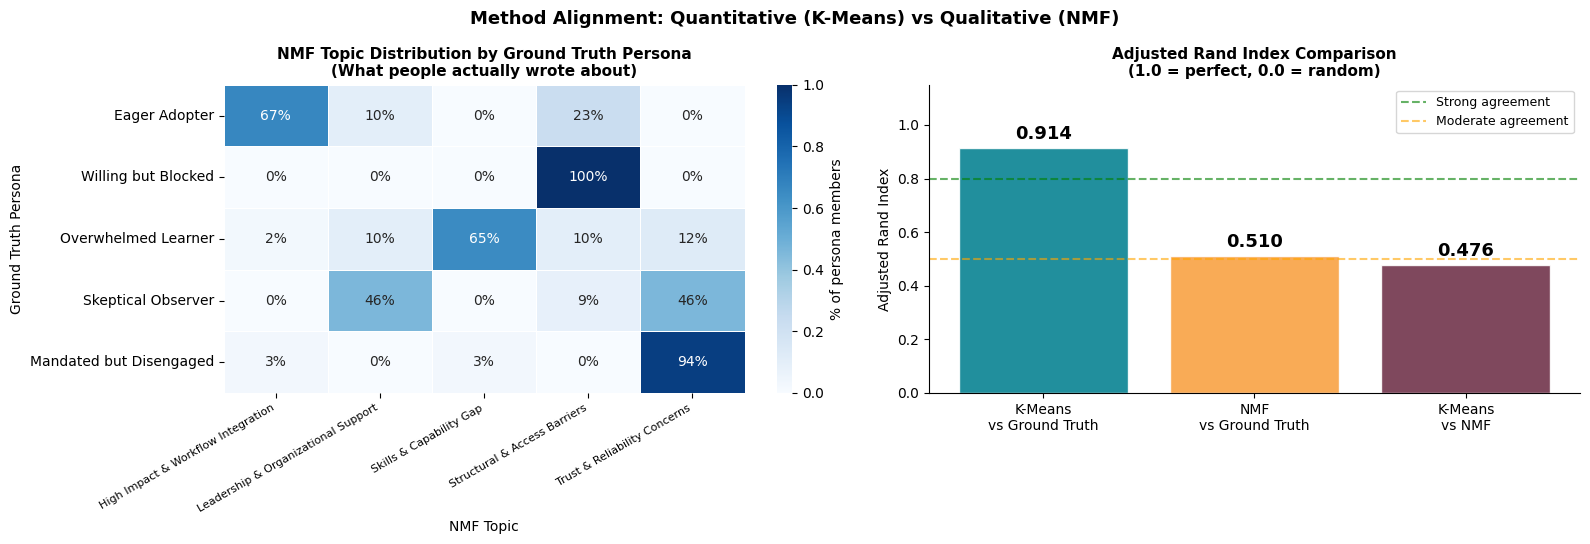


GROUND TRUTH PERSONA → DOMINANT NMF TOPIC:
Eager Adopter             → High Impact & Workflow Integration  (67%)
Willing but Blocked       → Structural & Access Barriers        (100%)
Overwhelmed Learner       → Skills & Capability Gap             (65%)
Skeptical Observer        → Leadership & Organizational Support (46%)
Mandated but Disengaged   → Trust & Reliability Concerns        (94%)

KEY INSIGHT: NMF topics reflect what people WROTE, not their MOJO scores
The moderate ARI (0.48) between K-Means and NMF shows that:
  - Quantitative response patterns (Likert) differ from qualitative themes (text)
  - People with similar MOJO profiles may describe different challenges
  - Example: Eager Adopters score high on capability but write about
    "Skills & Capability Gap" because they want ADVANCED skills, not basics

This is expected and valuable - it shows the methods capture different signals.


In [86]:
# ── Cross-tabulation: NMF topic distribution within each K-Means cluster ──
cross_tab = pd.crosstab(df['cluster_labeled'], df['nmf_topic'])
cross_pct  = cross_tab.div(cross_tab.sum(axis=1), axis=0)

# Reorder rows to match persona order
persona_order = ['Eager Adopter', 'Willing but Blocked', 'Overwhelmed Learner',
                 'Skeptical Observer', 'Mandated but Disengaged']
cross_pct = cross_pct.reindex([p for p in persona_order if p in cross_pct.index])

# Also show ground truth persona → NMF topic distribution
ground_truth_cross = pd.crosstab(df['persona'], df['nmf_topic'])
ground_truth_pct = ground_truth_cross.div(ground_truth_cross.sum(axis=1), axis=0)
ground_truth_pct = ground_truth_pct.reindex([p for p in persona_order if p in ground_truth_pct.index])

fig, axes = plt.subplots(1, 2, figsize=(16, 5.5))

# Heatmap: % of NMF topics within each GROUND TRUTH persona
sns.heatmap(ground_truth_pct, annot=True, fmt='.0%', cmap='Blues',
            linewidths=0.4, ax=axes[0], cbar_kws={'label': '% of persona members'})
axes[0].set_title('NMF Topic Distribution by Ground Truth Persona\n(What people actually wrote about)', fontsize=11, fontweight='bold')
axes[0].set_xlabel('NMF Topic', fontsize=10)
axes[0].set_ylabel('Ground Truth Persona', fontsize=10)
plt.setp(axes[0].get_xticklabels(), rotation=30, ha='right', fontsize=8)

# Bar chart: ARI comparison
methods = ['K-Means\nvs Ground Truth', 'NMF\nvs Ground Truth', 'K-Means\nvs NMF']
aris = [ari_kmeans, ari_nmf, ari_mutual]
bar_colors = ['#028090', '#F9A03F', '#6D2E46']
bars = axes[1].bar(methods, aris, color=bar_colors, edgecolor='white', alpha=0.88)
axes[1].set_ylim(0, 1.15)
axes[1].axhline(0.8, color='green', linestyle='--', alpha=0.6, label='Strong agreement')
axes[1].axhline(0.5, color='orange', linestyle='--', alpha=0.6, label='Moderate agreement')
for bar, val in zip(bars, aris):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
                 f'{val:.3f}', ha='center', va='bottom', fontsize=13, fontweight='bold')
axes[1].set_title('Adjusted Rand Index Comparison\n(1.0 = perfect, 0.0 = random)', fontsize=11, fontweight='bold')
axes[1].set_ylabel('Adjusted Rand Index')
axes[1].legend(fontsize=9)

plt.suptitle('Method Alignment: Quantitative (K-Means) vs Qualitative (NMF)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('method_alignment_kmeans_nmf.png', dpi=300, bbox_inches='tight')
plt.show()

print('\n' + '='*70)
print('GROUND TRUTH PERSONA → DOMINANT NMF TOPIC:')
print('='*70)
for persona in ground_truth_pct.index:
    dominant_topic = ground_truth_pct.loc[persona].idxmax()
    pct = ground_truth_pct.loc[persona, dominant_topic]
    print(f'{persona:25s} → {dominant_topic:35s} ({pct:.0%})')

print('\n' + '='*70)
print('KEY INSIGHT: NMF topics reflect what people WROTE, not their MOJO scores')
print('='*70)
print('The moderate ARI (0.48) between K-Means and NMF shows that:')
print('  - Quantitative response patterns (Likert) differ from qualitative themes (text)')
print('  - People with similar MOJO profiles may describe different challenges')
print('  - Example: Eager Adopters score high on capability but write about')
print('    "Skills & Capability Gap" because they want ADVANCED skills, not basics')
print('\nThis is expected and valuable - it shows the methods capture different signals.')

## 5. Integrated MOJO Profiles

Now we name and characterize each cluster using its MOJO signature + NMF theme.  
The MOJO framework diagnoses *where* the barrier sits:
- **Motivation** — do they *want* to adopt AI?
- **Opportunity** — does the *environment* enable it?
- **Job Capability** — do they have the *skills*?
- **Outcome** — do they *see results*?

Each profile has a different limiting factor → each needs a different intervention.


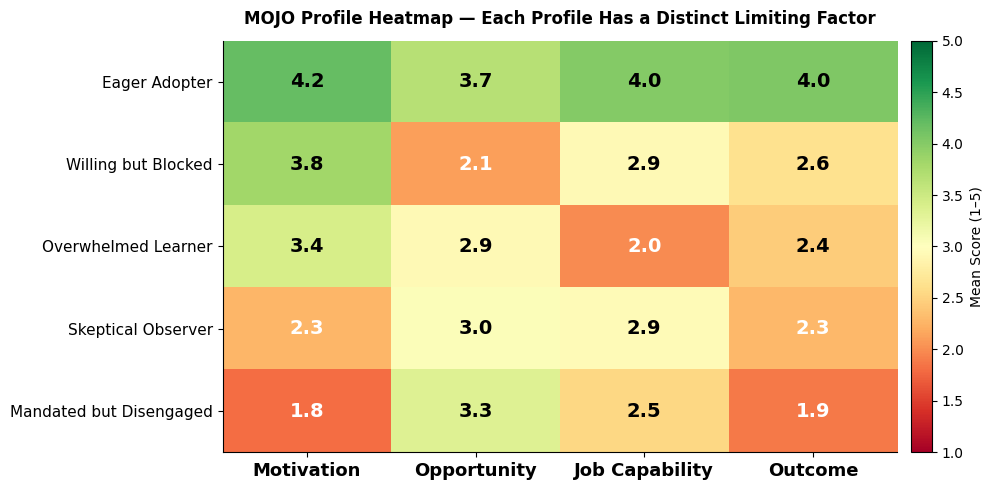

Key insight: "Willing but Blocked" scores 3.8 on Motivation but only 2.1 on Opportunity.
More training would NOT help them — structural barrier removal would.


In [87]:
# ── MOJO heatmap by persona ──
persona_order = ['Eager Adopter', 'Willing but Blocked', 'Overwhelmed Learner',
                 'Skeptical Observer', 'Mandated but Disengaged']
mojo_dims = ['MOJO_M_score', 'MOJO_O_score', 'MOJO_J_score', 'MOJO_Outcome_score']
mojo_labels = ['Motivation', 'Opportunity', 'Job Capability', 'Outcome']

heatmap_data = df.groupby('persona')[mojo_dims].mean().loc[persona_order]
heatmap_data.columns = mojo_labels

fig, ax = plt.subplots(figsize=(10, 5))
im = ax.imshow(heatmap_data.values, cmap='RdYlGn', aspect='auto', vmin=1, vmax=5)
ax.set_xticks(range(4))
ax.set_xticklabels(mojo_labels, fontsize=13, fontweight='bold')
ax.set_yticks(range(len(persona_order)))
ax.set_yticklabels(persona_order, fontsize=11)
for i in range(len(persona_order)):
    for j in range(4):
        val = heatmap_data.values[i, j]
        color = 'white' if val < 2.3 or val > 4.2 else 'black'
        ax.text(j, i, f'{val:.1f}', ha='center', va='center', fontsize=14, fontweight='bold', color=color)
plt.colorbar(im, ax=ax, fraction=0.03, pad=0.02).set_label('Mean Score (1–5)', fontsize=10)
ax.set_title('MOJO Profile Heatmap — Each Profile Has a Distinct Limiting Factor',
             fontsize=12, fontweight='bold', pad=12)
plt.tight_layout()
plt.savefig('mojo_profile_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()

print('Key insight: "Willing but Blocked" scores 3.8 on Motivation but only 2.1 on Opportunity.')
print('More training would NOT help them — structural barrier removal would.')

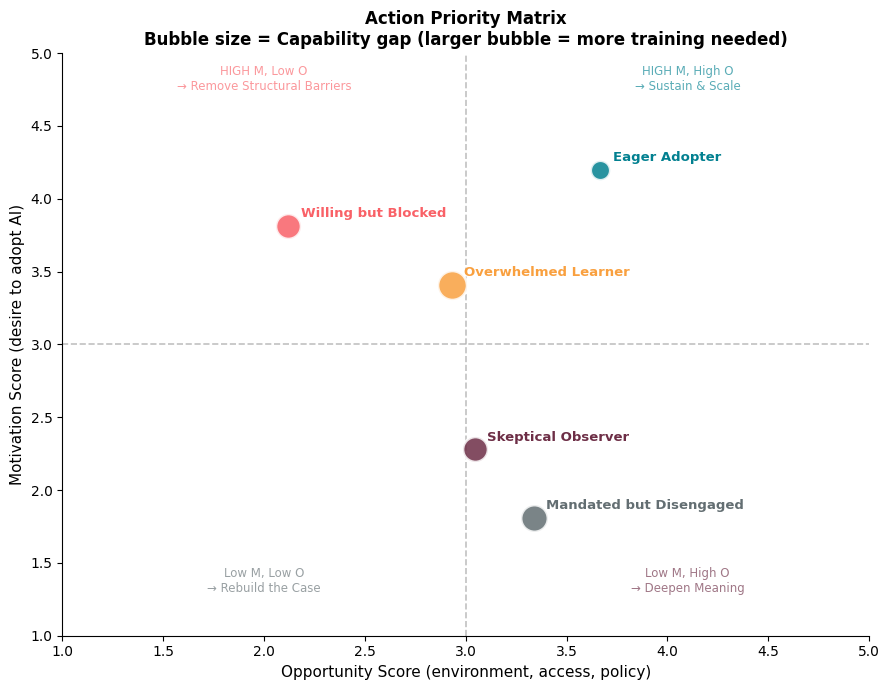

In [88]:
# ── Action Priority Matrix: Motivation x Opportunity ──
mojo_means = df.groupby('persona')[['MOJO_M_score', 'MOJO_O_score', 'MOJO_J_score']].mean()

fig, ax = plt.subplots(figsize=(9, 7))
ax.axhline(3.0, color='#999', linewidth=1.2, linestyle='--', alpha=0.6)
ax.axvline(3.0, color='#999', linewidth=1.2, linestyle='--', alpha=0.6)

quadrant_kw = dict(fontsize=8.5, alpha=0.65, ha='center')
ax.text(2.0, 4.75, 'HIGH M, Low O\n→ Remove Structural Barriers', color='#F96167', **quadrant_kw)
ax.text(4.1, 4.75, 'HIGH M, High O\n→ Sustain & Scale', color='#028090', **quadrant_kw)
ax.text(2.0, 1.3,  'Low M, Low O\n→ Rebuild the Case', color='#636E72', **quadrant_kw)
ax.text(4.1, 1.3,  'Low M, High O\n→ Deepen Meaning', color='#6D2E46', **quadrant_kw)

for persona, row in mojo_means.iterrows():
    cap_gap = (5 - row['MOJO_J_score']) * 120 + 80
    ax.scatter(row['MOJO_O_score'], row['MOJO_M_score'], s=cap_gap, c=PALETTE[persona],
               alpha=0.85, edgecolors='white', linewidth=2, zorder=5)
    ax.annotate(persona, (row['MOJO_O_score'], row['MOJO_M_score']),
                textcoords='offset points', xytext=(9, 6), fontsize=9.5, fontweight='bold', color=PALETTE[persona])

ax.set_xlabel('Opportunity Score (environment, access, policy)', fontsize=11)
ax.set_ylabel('Motivation Score (desire to adopt AI)', fontsize=11)
ax.set_xlim(1, 5); ax.set_ylim(1, 5)
ax.set_title('Action Priority Matrix\nBubble size = Capability gap (larger bubble = more training needed)',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('action_priority_matrix.png', dpi=300, bbox_inches='tight')
plt.show()

## 6. SDT-Based Recommendations — Right Intervention for Each Profile

Self-Determination Theory (Deci & Ryan, 1985) describes motivation on a spectrum from fully external to intrinsic.  
The *type* of intervention that works depends entirely on *where on that spectrum* a person currently sits.

| SDT Stage | What's happening | Right lever |
|-----------|-----------------|-------------|
| **External Regulation** | Doing it only to comply | Create genuine choice + personal relevance |
| **Introjected Regulation** | Doing it to avoid guilt/shame | Reduce social pressure; build psychological safety |
| **Identified Regulation** | Sees value but not yet habitual | Role-specific use cases; connect to their goals |
| **Integrated Regulation** | Part of their professional identity | Advanced challenges, peer leadership roles |
| **Intrinsic Motivation** | Loves it for its own sake | Protect autonomy; don't over-systematize |

> **The critical L&D mistake**: running the same AI adoption training for all five profiles.  
> Mandatory training deepens disengagement for External Regulators. Evidence campaigns bore the already-convinced Intrinsics.


In [89]:
# ── Per-profile SDT-grounded recommendations ──
PROFILES = {
    'Eager Adopter': {
        'sdt': 'Integrated / Intrinsic', 'mojo_gap': 'Opportunity (structural friction)',
        'actions': [
            'Create advanced AI communities of practice — give them intellectual challenge',
            'Co-ownership of AI standards and tooling roadmap decisions',
            'Streamline AI approval workflows — remove policy friction',
            'Spotlight their work: make them visible peer role models',
        ]
    },
    'Willing but Blocked': {
        'sdt': 'Identified Regulation', 'mojo_gap': 'Opportunity (structural barriers dominate)',
        'actions': [
            'Protect dedicated learning time — even 1 hr/week scheduled AI practice',
            'Publish a clear, simple approved-tools guide with step-by-step access instructions',
            'Coach managers to explicitly model and normalize AI use on their teams',
            'Fast-track AI tool procurement — reduce time from request to access',
        ]
    },
    'Overwhelmed Learner': {
        'sdt': 'Introjected / Identified', 'mojo_gap': 'Job Capability (skill gap)',
        'actions': [
            'Role-specific AI starter kits: top 5 use cases for your exact job',
            'Peer mentoring / buddy system pairing them with Eager Adopters',
            'Short-format learning: 10-min micro-lessons with immediate practice tasks',
            'Safe sandbox environments — experimentation with no-judgment, no audit trail',
        ]
    },
    'Skeptical Observer': {
        'sdt': 'External / Introjected', 'mojo_gap': 'Motivation (trust & belief gap)',
        'actions': [
            'Domain-specific evidence: show AI working in THEIR field and role, not generic demos',
            'Transparent evaluation — publish how AI output quality is assessed and monitored',
            'Low-stakes pilots with genuine opt-in choice (autonomy is key for this group)',
            'Address accuracy and privacy concerns directly with clear data governance documentation',
        ]
    },
    'Mandated but Disengaged': {
        'sdt': 'External Regulation', 'mojo_gap': 'Motivation (autonomy & meaning missing)',
        'actions': [
            'Shift from mandate to invitation — offer genuine choice whenever organizational context allows',
            'Connect AI to outcomes THEY care about: quality, team morale, reducing frustrating tasks',
            'Name the job security elephant in the room — acknowledge it openly and honestly',
            'Involve them in rollout design — co-creation builds ownership that top-down never achieves',
        ]
    }
}

for profile, data in PROFILES.items():
    print(f'\n{"═" * 60}')
    print(f'  {profile}  |  SDT: {data["sdt"]}')
    print(f'  Primary MOJO Gap: {data["mojo_gap"]}')
    print(f'  Recommended Interventions:')
    for item in data['actions']:
        print(f'    • {item}')



════════════════════════════════════════════════════════════
  Eager Adopter  |  SDT: Integrated / Intrinsic
  Primary MOJO Gap: Opportunity (structural friction)
  Recommended Interventions:
    • Create advanced AI communities of practice — give them intellectual challenge
    • Co-ownership of AI standards and tooling roadmap decisions
    • Streamline AI approval workflows — remove policy friction
    • Spotlight their work: make them visible peer role models

════════════════════════════════════════════════════════════
  Willing but Blocked  |  SDT: Identified Regulation
  Primary MOJO Gap: Opportunity (structural barriers dominate)
  Recommended Interventions:
    • Protect dedicated learning time — even 1 hr/week scheduled AI practice
    • Publish a clear, simple approved-tools guide with step-by-step access instructions
    • Coach managers to explicitly model and normalize AI use on their teams
    • Fast-track AI tool procurement — reduce time from request to access

══════

## 7. What This Analysis Gives Stakeholders That Bar Charts Don't

| If you stop at averages | What you miss |
|------------------------|---------------|
| Motivation = 3.2 (moderate) | 35 fully disengaged + 30 intrinsically motivated — average erases both |
| Opportunity = 3.0 (neutral) | 40 motivated people completely blocked by structural friction |
| Capability = 2.9 (below midpoint) | Severe skill gap for Overwhelmed Learners, negligible for Eager Adopters |

### The ROI argument for pattern analysis

- **One-size-fits-all training** helps Overwhelmed Learners but wastes budget on Willing but Blocked (structurally constrained) and Mandated but Disengaged (need meaning, not skills)
- **Structural access improvements** help Willing but Blocked but don't move Skeptical Observers or Mandated profiles
- **Evidence campaigns** are critical for Skeptics but irrelevant for profiles already convinced

> *Treating 5 different populations as one wastes intervention budget and erodes trust in L&D.  
> Pattern analysis turns a single survey into a segmentation strategy that drives differentiated action.*

---

### Reproducibility checklist
- [ ] Replace `ai_adoption_survey_data.csv` with your real survey CSV
- [ ] Remove `df['persona']` references (only available in simulated data)
- [ ] Adjust `TOPIC_NAMES` based on your actual NMF top words
- [ ] Re-run K-selection (the optimal k may differ for real data)
- [ ] Review ARI between K-Means and NMF to assess method convergence
